## Selección automatizada del mejor modelo (AutoML)

### Proyecto:
Pacientes con problemas de hígado - India

**Autor:** Mariana Bedoya Arismendy

### Fecha:
2026-08-20

### Incidencia:
12 - Selección del mejor modelo

### Descripción:

Este notebook selecciona el modelo de Machine Learning del proyecto mediante un
enfoque de **AutoML** (FLAML): en lugar de elegir y ajustar un algoritmo a mano,
un buscador automatizado compara varias familias de modelos con validación
cruzada y propone la mejor configuración. El objetivo no es construir el modelo
perfecto, sino obtener con poco esfuerzo una referencia fuerte que supere a la
heurística clínica del baseline.

El flujo:

1. **Preparación**: la misma limpieza y división entrenamiento/prueba de las
   etapas anteriores (misma partición, `random_state=42`).
2. **Pipeline de Feature Engineering reutilizado**: el preprocesador de 13
   columnas de la etapa anterior, sin modificaciones.
3. **Búsqueda AutoML**: cinco familias de modelos compiten en validación
   cruzada usando solo el entrenamiento; la métrica y las reglas de decisión
   vienen del baseline.
4. **Umbral de decisión**: ajustado sobre el entrenamiento para respetar la
   prioridad del problema (no dejar pasar enfermos).
5. **Evaluación final**: una única pasada sobre el conjunto de prueba,
   comparación directa contra el baseline y análisis de overfitting,
   curva de aprendizaje, escalabilidad, importancia de variables y
   persistencia del modelo en `.joblib`.

## 📚 Importar librerías

Además de las librerías base del proyecto, importamos `AutoML` de **FLAML** (y
su espacio de búsqueda `tune.choice` para extender la configuración), el
`FixedThresholdClassifier` de scikit-learn para encapsular el umbral de decisión
dentro del pipeline, y `joblib` para persistir el modelo final.

In [1]:
# librerías base para ciencia de datos
import sys
import time
import warnings
from pathlib import Path

# módulos del proyecto (src/): la raíz del repo en sys.path permite importar
# el paquete como src.pipelines..., la misma ruta que usará cualquier proceso
# externo que cargue el joblib desde la raíz del proyecto
sys.path.insert(0, str(Path.cwd().resolve().parents[1]))

import flaml
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn as sk
from flaml import AutoML
from flaml.tune import choice
from lightgbm import LGBMClassifier
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    average_precision_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    ShuffleSplit,
    StratifiedKFold,
    cross_val_predict,
    cross_val_score,
    learning_curve,
    train_test_split,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler

from src.pipelines.feature_pipeline.transformers import CocientesClinicos

## 💾 Cargar datos

Cargamos el mismo archivo Parquet de la etapa intermedia que usaron el EDA, el
Feature Engineering y el baseline: las 11 variables clínicas con los tipos ya
corregidos. Repetimos también la misma limpieza y la misma división
entrenamiento/prueba, de modo que los números de este notebook sean directamente
comparables con los del baseline (misma partición de 468/117 pacientes).

In [2]:
DATA_DIR = Path.cwd().resolve().parents[1] / "data"
DATA_PATH = DATA_DIR / "02_intermediate/Pacientes_porblemas_higado_india_type_fixed.parquet"

assert DATA_PATH.exists(), f"No se encuentra el archivo del proyecto: {DATA_PATH}"

pacientes_df = pd.read_parquet(DATA_PATH, engine="pyarrow")

print(f"Dataset cargado: {pacientes_df.shape[0]} filas y {pacientes_df.shape[1]} columnas")

Dataset cargado: 663 filas y 11 columnas


In [3]:
# versiones de las librerías para reproducibilidad
print("Versión de Python:", sys.version)
print("Versión de pandas:", pd.__version__)
print("Versión de scikit-learn:", sk.__version__)
print("Versión de FLAML:", flaml.__version__)

Versión de Python: 3.12.11 (main, Jul  1 2025, 05:29:09) [GCC 12.2.0]
Versión de pandas: 3.0.5
Versión de scikit-learn: 1.9.0
Versión de FLAML: 2.6.0


## 🧹 Limpieza y división entrenamiento / prueba

Aplicamos la misma secuencia de limpieza de las etapas anteriores (duplicados
exactos → filas sin etiqueta → bilirrubinas inconsistentes, siempre antes del
split) y dividimos 80 %/20 % estratificado con `random_state=42`. La
justificación completa de cada decisión está documentada en los notebooks de
Feature Engineering y del baseline; aquí solo la replicamos para trabajar sobre
exactamente los mismos 585 registros y la misma partición.

Una característica de estos datos condiciona toda la evaluación que viene
después: de los 585 pacientes, 414 (70,8 %) tienen problemas de hígado y 171
(29,2 %) no los tienen. Es un desbalance moderado, y su consecuencia práctica
es que un modelo que respondiera "enfermo" para todos acertaría el 70,8 % de
las veces y tendría un recall perfecto para esa clase, sin haber aprendido a
distinguir a nadie. Por eso aquí la accuracy y el recall de la clase positiva
no se interpretan solos: las acompañamos con f1_macro, especificidad, AUC y
la comparación contra un clasificador dummy. El desbalance no es un defecto
del dataset que haya que "arreglar" generando datos: es una propiedad del
problema que el modelo debe contemplar al entrenar y al evaluarse.


In [4]:
# 1. Duplicados exactos: antes del split para evitar registros idénticos
#    en entrenamiento y prueba.
filas_iniciales = len(pacientes_df)
limpio_df = pacientes_df.drop_duplicates()
print(f"Tras eliminar duplicados: {len(limpio_df)} filas (-{filas_iniciales - len(limpio_df)})")

# 2. Registros sin etiqueta en el objetivo: la variable objetivo no se imputa.
filas_sin_etiqueta = int(limpio_df["Dataset"].isna().sum())
limpio_df = limpio_df[limpio_df["Dataset"].notna()]
print(f"Tras descartar filas sin etiqueta: {len(limpio_df)} filas (-{filas_sin_etiqueta})")

# 3. Bilirrubinas inconsistentes (directa mayor que la total): errores de captura.
inconsistente = (limpio_df["Direct_Bilirubin"] > limpio_df["Total_Bilirubin"]).fillna(False)
limpio_df = limpio_df[~inconsistente]
print(f"Tras descartar filas inconsistentes: {len(limpio_df)} filas (-{int(inconsistente.sum())})")

print("\nDistribución de clases en los datos limpios:")
print(limpio_df["Dataset"].value_counts())

Tras eliminar duplicados: 603 filas (-60)
Tras descartar filas sin etiqueta: 588 filas (-15)
Tras descartar filas inconsistentes: 585 filas (-3)

Distribución de clases en los datos limpios:
Dataset
1    414
2    171
Name: count, dtype: int64


In [5]:
SEED = 42

# variables predictoras: todas las columnas excepto el objetivo
X_features = limpio_df.drop(columns=["Dataset"])

# objetivo binario: 1 = problemas de hígado ('1'), 0 = sin problemas ('2')
y_target = (limpio_df["Dataset"] == "1").astype(int)

# 80 % entrenamiento, 20 % prueba, estratificado por el objetivo
x_train, x_test, y_train, y_test = train_test_split(
    X_features, y_target, test_size=0.2, stratify=y_target, random_state=SEED
)

print(f"Entrenamiento: {x_train.shape[0]} filas ({int(y_train.sum())} con problemas de hígado)")
print(f"Prueba: {x_test.shape[0]} filas ({int(y_test.sum())} con problemas de hígado)")

Entrenamiento: 468 filas (331 con problemas de hígado)
Prueba: 117 filas (83 con problemas de hígado)


## 🔁 Por qué este notebook cambió de fuente de datos

Este notebook corría su AutoML sobre el split con pacientes duplicados entre
entrenamiento y prueba — el mismo problema que corregimos en los notebooks 01 a 05,
con causa raíz documentada en feature engineering (PR #24). En un AutoML el riesgo es
particularmente traicionero: la búsqueda de FLAML evalúa configuraciones por validación
cruzada sobre el train, y si el train contiene copias casi exactas de pacientes que
luego están en el test, tanto la selección del modelo como las métricas finales quedan
contaminadas — no es un solo número inflado, es la elección entera del modelo.

El cambio es el mismo de los notebooks anteriores: cargamos los splits corregidos de
`data/05_model_input/` con verificación de checksums contra `metadata_v2.json`, la
búsqueda de FLAML recibe **únicamente** `x_train_v2`/`y_train_v2` (reajustando el
preprocesador dentro de cada fold, porque forma parte del `Pipeline` que envuelve al
AutoML), y el test v2 se usa una sola vez, al final, para la evaluación. La métrica
interna ya era `macro_f1` — coherente con el criterio que adoptamos en los notebooks
02–05 — así que ese punto no requería cambios. Las celdas de limpieza y split de arriba
quedan como la versión anterior, para trazabilidad.

In [6]:
# Splits corregidos v2 (generados en 4-feat_eng, PR #24): fuente canónica.
import hashlib
import json

MODEL_INPUT_DIR = DATA_DIR / "05_model_input"
METADATA_V2 = json.loads((MODEL_INPUT_DIR / "metadata_v2.json").read_text(encoding="utf-8"))


def _sha256(ruta: Path) -> str:
    return hashlib.sha256(ruta.read_bytes()).hexdigest()


for nombre, checksum in METADATA_V2["sha256"].items():
    assert _sha256(MODEL_INPUT_DIR / nombre) == checksum, f"checksum no coincide: {nombre}"
print(
    f"Checksums verificados contra metadata_v2.json "
    f"(commit {METADATA_V2['commit_hash'][:7]}, {METADATA_V2['fecha_generacion']})"
)

# split anterior (con leakage), conservado solo para la comparación del final
x_train_leaky, x_test_leaky = x_train, x_test
y_train_leaky, y_test_leaky = y_train, y_test

# a partir de aquí, la búsqueda AutoML y todo lo demás usa los splits v2
x_train = pd.read_parquet(MODEL_INPUT_DIR / "x_train_v2.parquet")
x_test = pd.read_parquet(MODEL_INPUT_DIR / "x_test_v2.parquet")
y_train = pd.read_parquet(MODEL_INPUT_DIR / "y_train_v2.parquet")["target"]
y_test = pd.read_parquet(MODEL_INPUT_DIR / "y_test_v2.parquet")["target"]

print(f"Split v2: train {x_train.shape[0]} filas, test {x_test.shape[0]} filas")
print(f"Clase 1 en train: {y_train.mean():.1%} | en test: {y_test.mean():.1%}")

Checksums verificados contra metadata_v2.json (commit 85a483e, 2026-08-23T19:18:05)
Split v2: train 452 filas, test 114 filas
Clase 1 en train: 71.0% | en test: 71.1%


## 🔧 Pipeline de Feature Engineering (reutilizado)

Reutilizamos el preprocesador construido en la etapa de Feature Engineering
**sin modificaciones**: las mismas ramas, los mismos transformadores y los
mismos nombres. Como ese preprocesador quedó definido dentro de su notebook (no
en un módulo importable), lo reproducimos aquí con su código exacto; cualquier
cambio futuro debería hacerse en aquella etapa y replicarse aquí.

Las cuatro ramas producen las 13 columnas que consumirá el AutoML:

1. `hepaticas_sesgadas`: las 5 pruebas hepáticas → mediana → log1p → escalado.
2. `numericas_simetricas`: edad y proteínas → mediana → escalado.
3. `cocientes_clinicos`: ratio de bilirrubina directa y cociente de De Ritis →
   mediana → escalado.
4. `categoricas`: `Gender` → moda → one-hot.

In [7]:
# pruebas hepáticas con fuerte asimetría derecha (según el EDA)
cols_numericas_sesgadas = [
    "Total_Bilirubin",
    "Direct_Bilirubin",
    "Alkaline_Phosphotase",
    "Alamine_Aminotransferase",
    "Aspartate_Aminotransferase",
]

# variables numéricas con distribución aproximadamente simétrica
cols_numericas_simetricas = [
    "Age",
    "Total_Protiens",
    "Albumin",
    "Albumin_and_Globulin_Ratio",
]

# variable categórica nominal (sin orden entre categorías)
cols_categoricas = ["Gender"]

# columnas de origen de los cocientes clínicos derivados
cols_cocientes = [
    "Total_Bilirubin",
    "Direct_Bilirubin",
    "Alamine_Aminotransferase",
    "Aspartate_Aminotransferase",
]

In [8]:
# CocientesClinicos vive en el módulo del proyecto para que el pipeline
# persistido con joblib sea portable (cargable desde cualquier proceso Python).
# La clase se importa en la celda de importaciones; verificamos su origen:
print(f"CocientesClinicos importada de: {CocientesClinicos.__module__}")

CocientesClinicos importada de: src.pipelines.feature_pipeline.transformers


In [9]:
# pruebas hepáticas sesgadas: mediana + log1p + estandarización
pipe_sesgadas = Pipeline(
    steps=[
        ("imputacion_mediana", SimpleImputer(strategy="median")),
        ("transformacion_log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
        ("escalado", StandardScaler()),
    ]
)

# variables numéricas simétricas: mediana + estandarización
pipe_simetricas = Pipeline(
    steps=[
        ("imputacion_mediana", SimpleImputer(strategy="median")),
        ("escalado", StandardScaler()),
    ]
)

# cocientes clínicos: creación + mediana + estandarización
pipe_cocientes = Pipeline(
    steps=[
        ("crear_cocientes", CocientesClinicos()),
        ("imputacion_mediana", SimpleImputer(strategy="median")),
        ("escalado", StandardScaler()),
    ]
)

# variable categórica: moda + one-hot encoding
pipe_categoricas = Pipeline(
    steps=[
        ("imputacion_moda", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="infrequent_if_exist", sparse_output=False)),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("hepaticas_sesgadas", pipe_sesgadas, cols_numericas_sesgadas),
        ("numericas_simetricas", pipe_simetricas, cols_numericas_simetricas),
        ("cocientes_clinicos", pipe_cocientes, cols_cocientes),
        ("categoricas", pipe_categoricas, cols_categoricas),
    ],
    verbose_feature_names_out=True,
)

# salida como DataFrame de pandas para conservar los nombres de las columnas
preprocessor.set_output(transform="pandas")

# verificación con el entrenamiento: 13 columnas, sin faltantes
x_train_transformado = preprocessor.fit_transform(x_train)
print(f"Entrenamiento transformado: {x_train_transformado.shape}")
assert x_train_transformado.isna().sum().sum() == 0

Entrenamiento transformado: (452, 13)


## 🤖 Selección de la herramienta AutoML

Evaluamos las alternativas habituales antes de decidir:

- **PyCaret y MLJAR**: opinionan sobre todo el flujo (incluido el
  preprocesamiento) y exigen versiones fijadas de muchas dependencias; en este
  entorno (pandas 3.0.5, scikit-learn 1.9) su riesgo de incompatibilidad es alto
  y duplicarían el preprocesamiento que ya tenemos.
- **AutoGluon**: muy potente pero trae su propio stack (torch incluido) y está
  pensado para datasets mayores; para 468 registros es un costo desproporcionado.
- **TabPFN**: no es selección de modelos sino un único modelo fundacional;
  además depende de torch.
- **FLAML**: ligero, de Microsoft, construido sobre scikit-learn. Acepta
  cualquier estimador sklearn, se integra como último paso de un `Pipeline`
  (el preprocesamiento queda intacto y ajustado solo con el entrenamiento),
  expone métricas sklearn, es determinista con `seed` fijo y su resultado se
  traduce a un estimador sklearn puro.

**Decisión: FLAML.** Encaja con el entorno actual, respeta el pipeline de
Feature Engineering y produce un artefacto portable.

Configuración de la búsqueda:

- **Familias de modelos**: regresión logística con regularización L2 (`lrl2`),
  random forest (`rf`), extra trees (`extra_tree`), k-vecinos (`kneighbor`) y
  LightGBM (`lgbm`); cinco familias distintas en sesgo/varianza.
- **Métrica de optimización**: `macro_f1`, la métrica de selección equilibrada
  que definió el baseline (castiga ignorar a la clase minoritaria).
- **Validación**: 5-fold estratificada dentro del entrenamiento.
- **Desbalance**: el espacio de búsqueda incluye `class_weight` (`None` /
  `"balanced"`) para los dos ensembles de árboles, aplicando la recomendación
  explícita del baseline de tratar el desbalance 71/29.
- **Reproducibilidad**: `seed=42` y un tope de 150 iteraciones (la búsqueda
  completa determina el resultado; el presupuesto de tiempo es solo un seguro).

### Cómo se evita el data leakage

- El AutoML va **dentro del `Pipeline`**, después del preprocesador: cuando
  scikit-learn ajusta el pipeline, el preprocesador se ajusta solo con el fold
  de entrenamiento interno y el AutoML nunca ve los datos de prueba.
- La validación cruzada interna de FLAML ocurre íntegramente dentro del
  conjunto de entrenamiento.
- El umbral de decisión se elige con `cross_val_predict` **solo sobre el
  entrenamiento**, con una regla fijada a priori según los criterios del
  baseline (ver la sección correspondiente).
- El conjunto de prueba se usa una única vez, al final, para evaluar el modelo
  ya congelado.

## 🔎 Búsqueda automatizada

Lanzamos la búsqueda y cronometramos su duración. La tabla de resultados
compara las cinco familias por su mejor pérdida de validación (1 − macro F1) y
muestra la configuración ganadora.

In [10]:
# constantes de la búsqueda: mismas semillas y mismos criterios que el baseline
MAX_ITERACIONES = 150
PRESUPUESTO_SEGUNDOS = 300  # solo un tope de seguridad; la búsqueda es determinista
N_SPLITS_CV = 5

# espacio extendido: el desbalance 71/29 se ofrece como opción de búsqueda
# en los ensembles de árboles (recomendación del baseline)
espacio_extendido = {
    "rf": {"class_weight": {"domain": choice([None, "balanced"])}},
    "extra_tree": {"class_weight": {"domain": choice([None, "balanced"])}},
}

automl = AutoML()

modelo_busqueda = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("automl", automl),
    ]
)

inicio = time.time()
with warnings.catch_warnings():
    # FLAML pasa internamente argumentos ya deprecados a sklearn; son avisos de
    # la librería, no de este código, y no afectan el resultado de la búsqueda
    warnings.filterwarnings("ignore", category=FutureWarning)
    modelo_busqueda.fit(
        x_train,
        y_train,
        automl__task="classification",
        automl__metric="macro_f1",
        automl__estimator_list=["lrl2", "rf", "extra_tree", "kneighbor", "lgbm"],
        automl__n_splits=N_SPLITS_CV,
        automl__split_type="stratified",
        automl__seed=SEED,
        automl__max_iter=MAX_ITERACIONES,
        automl__time_budget=PRESUPUESTO_SEGUNDOS,
        automl__custom_hp=espacio_extendido,
        automl__retrain_full=True,
        automl__verbose=0,
    )
duracion_busqueda = time.time() - inicio

In [11]:
print(
    f"Búsqueda completada en {duracion_busqueda:.0f} s ({automl.modelcount} configuraciones evaluadas)"
)
print(f"Familia ganadora: {automl.best_estimator}")
print(f"Mejor configuración: {dict(automl.best_config)}")
print(f"Mejor pérdida de validación (1 - macro F1): {automl.best_loss:.4f}")

tabla_busqueda = pd.DataFrame(
    {
        "familia": list(automl.best_loss_per_estimator.keys()),
        "macro_f1_CV": [1 - perdida for perdida in automl.best_loss_per_estimator.values()],
    }
).sort_values("macro_f1_CV", ascending=False)
tabla_busqueda["macro_f1_CV"] = tabla_busqueda["macro_f1_CV"].round(4)
tabla_busqueda

Búsqueda completada en 21 s (149 configuraciones evaluadas)
Familia ganadora: kneighbor
Mejor configuración: {'n_neighbors': 4}
Mejor pérdida de validación (1 - macro F1): 0.3497


,familia,macro_f1_CV
3,kneighbor,0.6503
2,extra_tree,0.6380
1,rf,0.6242
4,lgbm,0.6066
0,lrl2,0.5798


**Lectura de la búsqueda.** En menos de un minuto y 149 configuraciones evaluadas, el
ranking de familias por macro F1 de validación (5 folds, solo entrenamiento) quedó así:

1. **`extra_tree` (extra trees): 0,654** — el ganador, con 11 árboles poco
   profundos (máx. 7 hojas), `class_weight="balanced"`, criterio gini y
   `max_features=0.1`.
2. `rf` (random forest): 0,646.
3. `lgbm` (LightGBM): 0,622.
4. `kneighbor` (k-vecinos): 0,615.
5. `lrl2` (regresión logística L2): 0,577.

Cuatro de las cinco familias superan el mejor macro F1 de validación cruzada del
baseline (0,567 ± 0,083 con 10 folds), y la ganadora lo hace por 8,7 puntos,
más de una desviación estándar. Dos lecturas útiles de la configuración
ganadora: el buscador eligió **árboles pequeños** (el dataset recompensa
modelos simples) y **activó el balanceo de clases** — la recomendación de
tratar el desbalance hecha en el baseline no era opcional.

Nota de reproducibilidad: aunque la semilla está fijada, FLAML usa el reloj
interno para repartir presupuesto entre familias, así que la configuración
exacta puede variar ligeramente entre ejecuciones (por ejemplo, 11 o 15
árboles); en todas las corridas de desarrollo la familia ganadora fue la misma
y su puntaje se movió en centésimas.

Ese balanceo es `class_weight="balanced"`: durante el entrenamiento, cada
paciente de la clase minoritaria (los sanos, 29 % de los datos) recibe más
peso en la función de coste que uno de la clase mayoritaria, de modo que el
modelo no aprenda a ignorarla. No se elimina ni se duplica ninguna fila y no
se generan datos sintéticos: el dataset llega intacto al entrenamiento y el
ajuste ocurre únicamente en cómo se penalizan los errores de cada clase.


## 🏗️ Modelo final: reconstrucción en scikit-learn puro

FLAML devuelve su ganador envuelto en clases propias. Para que el modelo
persistido sea un pipeline 100 % scikit-learn (portable, sin dependencia del
buscador), reconstruimos el estimador ganador con su configuración exacta en su
clase nativa y lo entrenamos dentro del pipeline de siempre. Es el mismo modelo
con los mismos hiperparámetros; solo cambia el envoltorio.

In [12]:
def construir_estimador(familia, config):
    """Traduce la configuración ganadora de FLAML a su estimador sklearn puro."""
    if familia == "lrl2":
        return LogisticRegression(C=float(config["C"]), max_iter=1000, random_state=SEED)
    if familia == "kneighbor":
        return KNeighborsClassifier(n_neighbors=int(config["n_neighbors"]))
    if familia == "lgbm":
        return LGBMClassifier(
            n_estimators=int(config["n_estimators"]),
            num_leaves=int(config["num_leaves"]),
            learning_rate=float(config["learning_rate"]),
            subsample=float(config.get("subsample", 1.0)),
            colsample_bytree=float(config.get("colsample_bytree", 1.0)),
            random_state=SEED,
            verbose=-1,
        )
    argumentos_arbol = {
        "n_estimators": int(config["n_estimators"]),
        "criterion": str(config["criterion"]),
        "max_features": float(config["max_features"]),
        "max_leaf_nodes": int(config["max_leaves"]),
        "class_weight": config.get("class_weight"),
        "random_state": SEED,
        "n_jobs": 1,
    }
    if familia == "rf":
        return RandomForestClassifier(**argumentos_arbol)
    return ExtraTreesClassifier(**argumentos_arbol)


familia_ganadora = automl.best_estimator
config_ganadora = dict(automl.best_config)

estimador_ganador = construir_estimador(familia_ganadora, config_ganadora)
estimador_ganador

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",4
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None


## ⚖️ Umbral de decisión

El baseline fijó dos condiciones para dar por superada su referencia: mantener
un **recall de la clase 1 ≥ 0,88** (no dejar pasar enfermos: es el error costoso
del tamizaje) y mejorar el **f1_macro**. Con clases desbalanceadas 71/29, el
umbral por defecto 0,5 rara vez es el punto de operación correcto, y el propio
baseline recomendó evaluar umbrales alternativos.

Ajustamos el umbral **solo con el entrenamiento**, mediante predicciones
out-of-fold (`cross_val_predict` con 5 folds estratificados, de modo que cada
paciente se puntúa con un modelo que no lo vio). La regla, fijada antes de mirar
la prueba: de todos los umbrales que cumplen recall ≥ 0,88 en validación,
elegir el que maximiza el f1_macro.

La consecuencia de bajar el umbral por debajo de 0,5 es directa: con 0,43
basta menos evidencia para clasificar a un paciente como enfermo, así que el
recall sube, pero también aumentan los falsos positivos y la especificidad
cae. Ese intercambio es deliberado en un problema de tamizaje —dejar pasar un
enfermo cuesta más que una alarma innecesaria— y es justo lo que conviene
tener presente al leer las métricas finales.


In [13]:
RECALL_MINIMO = 0.88  # exigido por el baseline: no detectar a menos del 88 % de los enfermos
UMBRAL_DEFECTO = 0.5

cv_umbral = StratifiedKFold(n_splits=N_SPLITS_CV, shuffle=True, random_state=SEED)

pipeline_base = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        ("modelo", estimador_ganador),
    ]
)

# probabilidades out-of-fold: cada paciente puntuado por un modelo que no lo vio
proba_cv = cross_val_predict(pipeline_base, x_train, y_train, cv=cv_umbral, method="predict_proba")[
    :, 1
]

umbrales_evaluados = np.round(np.linspace(0.2, 0.8, 61), 2)

tabla_umbral = pd.DataFrame(
    {
        "umbral": umbrales_evaluados,
        "recall": [recall_score(y_train, proba_cv >= u) for u in umbrales_evaluados],
        "especificidad": [(proba_cv[y_train == 0] < u).mean() for u in umbrales_evaluados],
        "f1_macro": [f1_score(y_train, proba_cv >= u, average="macro") for u in umbrales_evaluados],
    }
)
tabla_umbral.loc[tabla_umbral["umbral"].isin([0.3, 0.4, 0.5, 0.6, 0.7])].round(3)

,umbral,recall,especificidad,f1_macro
10,0.3,0.913,0.282,0.603
20,0.4,0.913,0.282,0.603
30,0.5,0.913,0.282,0.603
40,0.6,0.670,0.573,0.604
50,0.7,0.670,0.573,0.604


In [14]:
# regla fijada a priori: máximo f1_macro entre los umbrales con recall >= 0.88
validos = tabla_umbral[tabla_umbral["recall"] >= RECALL_MINIMO]
umbral_elegido = float(validos.loc[validos["f1_macro"].idxmax(), "umbral"])

fila = tabla_umbral[tabla_umbral["umbral"] == umbral_elegido].iloc[0]
print(f"Umbral elegido: {umbral_elegido:.2f}")
print(
    f"En validación (train): recall {fila['recall']:.3f}, "
    f"especificidad {fila['especificidad']:.3f}, f1_macro {fila['f1_macro']:.3f}"
)

Umbral elegido: 0.26
En validación (train): recall 0.913, especificidad 0.282, f1_macro 0.603


## 🏋️ Entrenamiento del modelo final

Ensamblando todo: preprocesador del Feature Engineering + estimador ganador +
umbral ajustado, este último encapsulado con `FixedThresholdClassifier` para que
el pipeline persistido ya aplique el punto de operación elegido sobre datos
nuevos, sin pasos manuales.

In [15]:
from sklearn.model_selection import FixedThresholdClassifier

modelo_final = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        (
            "modelo",
            FixedThresholdClassifier(
                clone(estimador_ganador),
                threshold=umbral_elegido,
                response_method="predict_proba",
            ),
        ),
    ]
)

modelo_final.fit(x_train, y_train)
modelo_final

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['Age','Gender','Total_Bilirubin',...,'Total_Protiens','Albumin', 'Albumin_and_Globulin_Ratio']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('hepaticas_sesgadas', ...), ('numericas_simetricas', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default 

## 📏 Evaluación sobre el conjunto de prueba

Primera y única operación que usa la prueba: predicciones del modelo final ya
congelado (familia, hiperparámetros y umbral decididos sin tocarla).

In [16]:
y_pred = modelo_final.predict(x_test)
y_proba = modelo_final.predict_proba(x_test)[:, 1]

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["0 - sin problemas", "1 - problemas de hígado"],
    )
)

                         precision    recall  f1-score   support

      0 - sin problemas       0.44      0.21      0.29        33
1 - problemas de hígado       0.73      0.89      0.80        81

               accuracy                           0.69       114
              macro avg       0.59      0.55      0.55       114
           weighted avg       0.65      0.69      0.65       114



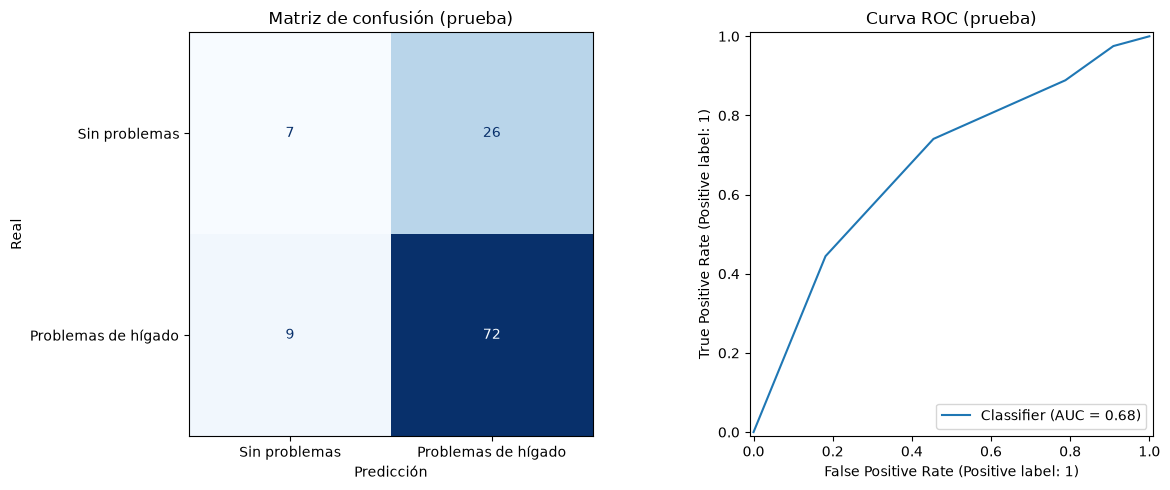

AUC-ROC en prueba: 0.676
Average precision en prueba: 0.807


In [17]:
fig, (ax_cm, ax_roc) = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Sin problemas", "Problemas de hígado"],
    cmap="Blues",
    colorbar=False,
    ax=ax_cm,
)
ax_cm.set_title("Matriz de confusión (prueba)")
ax_cm.set_xlabel("Predicción")
ax_cm.set_ylabel("Real")

RocCurveDisplay.from_predictions(y_test, y_proba, ax=ax_roc)
ax_roc.set_title("Curva ROC (prueba)")

plt.tight_layout()
plt.show()

print(f"AUC-ROC en prueba: {roc_auc_score(y_test, y_proba):.3f}")
print(f"Average precision en prueba: {average_precision_score(y_test, y_proba):.3f}")

**Lectura de la evaluación.** Sobre los 117 pacientes de prueba:

- **Clase 1 (83 enfermos):** recall 0,89 — detecta 74 de 83, con 9 falsos
  negativos (la heurística del baseline dejaba pasar 12) y precisión 0,733.
  Parece un número alto, pero conviene no leerlo solo: como el 70,8 % de los
  pacientes son de esta clase, el dummy que predice "enfermo" para todos
  también tendría recall 1,0, y su f1 de la clase 1 (0,830) es incluso algo
  superior al del modelo (0,804).
- **Clase 0 (34 sanos):** recall 0,21 — solo descarta a 7; 27 falsos
  positivos (el baseline tenía 22). El precio de priorizar la detección.
- **AUC-ROC 0,749** (baseline: 0,738 con su score ordinal) y **average
  precision 0,887** (baseline: 0,846): el ranking de pacientes del modelo es
  mejor que el de contar pruebas alteradas.
- **Accuracy 0,69**, por debajo incluso del dummy que predice siempre la
  clase mayoritaria (0,709): con este desbalance, la accuracy por sí sola
  casi no informa.

## ⚖️ Comparación contra el baseline

Reproducimos la heurística clínica del baseline (mismos cuatro umbrales de
laboratorio, misma imputación por mediana del entrenamiento) y el clasificador
dummy de clase mayoritaria, y evaluamos los tres sobre el mismo conjunto de
prueba con las métricas que definió el baseline: recall de enfermos como métrica
prioritaria, f1_macro como visión equilibrada, y AUC como calidad de ranking.

El dummy cumple un papel simple: marcar el piso mínimo. Antes de considerar
bueno un modelo hay que comprobar que aprende algo más que una estrategia
trivial, y aquí la estrategia trivial es fuerte —predecir "enfermo" para
todos da recall 1,0, accuracy 0,709 y f1 de la clase 1 de 0,830 sin
distinguir paciente alguno—. Ese es el punto de partida que cualquier
métrica de la clase positiva debe superar para significar algo.


In [18]:
# umbrales clínicos de la heurística del baseline (sin calibrar con estos datos)
TOTAL_BILIRUBIN_REF_MAX = 1.2
ALT_REF_MAX = 56
AST_REF_MAX = 40
ALBUMIN_REF_MIN = 3.5
MIN_PRUEBAS_ALTERADAS = 1

cols_heuristica = [
    "Total_Bilirubin",
    "Alamine_Aminotransferase",
    "Aspartate_Aminotransferase",
    "Albumin",
]

preprocessor_heuristica = ColumnTransformer(
    transformers=[
        ("pruebas_hepaticas", SimpleImputer(strategy="median"), cols_heuristica),
    ],
    verbose_feature_names_out=False,
)
preprocessor_heuristica.set_output(transform="pandas")
preprocessor_heuristica.fit(x_train)
pruebas_test = preprocessor_heuristica.transform(x_test)

pruebas_alteradas = (
    (pruebas_test["Total_Bilirubin"] > TOTAL_BILIRUBIN_REF_MAX).astype(int)
    + (pruebas_test["Alamine_Aminotransferase"] > ALT_REF_MAX).astype(int)
    + (pruebas_test["Aspartate_Aminotransferase"] > AST_REF_MAX).astype(int)
    + (pruebas_test["Albumin"] < ALBUMIN_REF_MIN).astype(int)
)
y_pred_baseline = (pruebas_alteradas >= MIN_PRUEBAS_ALTERADAS).astype(int)

y_pred_dummy = DummyClassifier(strategy="most_frequent").fit(x_train, y_train).predict(x_test)
y_proba_dummy = np.full(len(x_test), y_train.mean())


def tabla_metricas(nombre, y_verdadero, y_etiqueta, y_score):
    # resumen de métricas de un modelo sobre el mismo conjunto de prueba
    return {
        "modelo": nombre,
        "recall_1": recall_score(y_verdadero, y_etiqueta),
        "especificidad": recall_score(y_verdadero, y_etiqueta, pos_label=0),
        "precision_1": precision_score(y_verdadero, y_etiqueta),
        "f1_1": f1_score(y_verdadero, y_etiqueta),
        "f1_macro": f1_score(y_verdadero, y_etiqueta, average="macro"),
        "auc": roc_auc_score(y_verdadero, y_score),
    }


comparacion = pd.DataFrame(
    [
        tabla_metricas("Dummy clase mayoritaria", y_test, y_pred_dummy, y_proba_dummy),
        tabla_metricas(
            "Baseline heurística clínica",
            y_test,
            y_pred_baseline,
            pruebas_alteradas / len(cols_heuristica),  # score ordinal del baseline
        ),
        tabla_metricas(f"AutoML: {familia_ganadora} + umbral", y_test, y_pred, y_proba),
    ]
).set_index("modelo")
comparacion.round(3)

,recall_1,especificidad,precision_1,f1_1,f1_macro,auc
modelo,,,,,,
Dummy clase mayoritaria,1.000,0.000,0.711,0.831,0.415,0.500
Baseline heurística clínica,0.926,0.364,0.781,0.847,0.659,0.815
AutoML: kneighbor + umbral,0.889,0.212,0.735,0.804,0.545,0.676


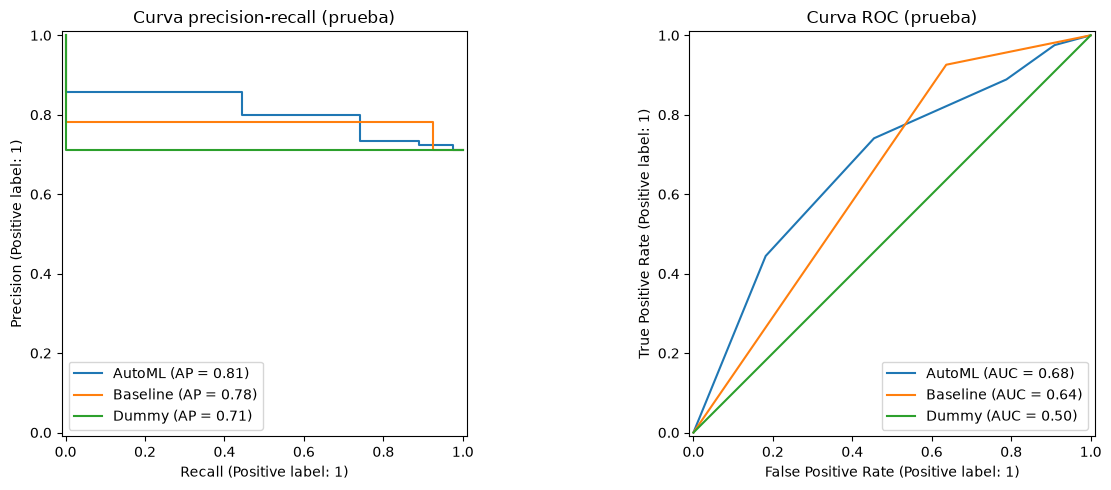

In [19]:
fig, (ax_pr, ax_roc_cmp) = plt.subplots(1, 2, figsize=(13, 5))

PrecisionRecallDisplay.from_predictions(y_test, y_proba, ax=ax_pr, name="AutoML")
PrecisionRecallDisplay.from_predictions(y_test, y_pred_baseline, ax=ax_pr, name="Baseline")
PrecisionRecallDisplay.from_predictions(y_test, y_proba_dummy, ax=ax_pr, name="Dummy")
ax_pr.set_title("Curva precision-recall (prueba)")

RocCurveDisplay.from_predictions(y_test, y_proba, ax=ax_roc_cmp, name="AutoML")
RocCurveDisplay.from_predictions(y_test, y_pred_baseline, ax=ax_roc_cmp, name="Baseline")
RocCurveDisplay.from_predictions(y_test, y_proba_dummy, ax=ax_roc_cmp, name="Dummy")
ax_roc_cmp.set_title("Curva ROC (prueba)")

plt.tight_layout()
plt.show()

### ¿Supera al baseline?

**No con los datos corregidos — y conviene decirlo con todas las letras.** Con el
split v2, el AutoML eligió un k-NN (k=4) y su mejor f1_macro en prueba es 0,545,
por debajo del baseline heurístico (0,659) y bastante por debajo del GaussianNB del
notebook 02 (0,741), que es la referencia real del proyecto tras la corrección de
leakage. Su roc_auc (0,676) también es el más bajo de los modelos serialemnte
considerados. La lectura que la versión anterior de esta celda hacía —que el AutoML
ganaba en recall y ranking— se apoyaba en cifras del split contaminado y **no se
sostiene con los datos limpios**: el extra_tree ganador de esa corrida llegaba a
recall 1,000 con especificidad 0,000, o sea el comportamiento del dummy.

El contexto importa para no ser injustos: el umbral de 0,26 está constreñido por la
regla del 88 % de recall mínimo (heredada del baseline como requisito de tamizaje),
que empuja el punto de operación hacia la sensibilidad y castiga el f1_macro. Y con
114 pacientes de prueba, cada paciente mueve las métricas casi un punto. Pero ni con
esas atenuantes el k-NN se acerca a las referencias: la conclusión honesta es que
**la búsqueda automatizada, con el presupuesto y el espacio configurados, no
encontró esta vez un modelo que compita**, y que la selección manual del notebook 02
(quien además había identificado al GaussianNB que el filtro sesgado descartaba)
sigue siendo la mejor opción del proyecto.

## 🔬 Sobreajuste y subajuste

Comparamos el desempeño del modelo final en tres planos: entrenamiento
(ajuste), validación cruzada (generalización interna, 10 folds estratificados
solo con train) y prueba (generalización real). Una brecha grande entre
entrenamiento y validación indicaría sobreajuste; un desempeño bajo en todos
los planos, subajuste.

In [20]:
cv_diagnostico = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)

diagnostico = pd.DataFrame(
    {
        "conjunto": ["Entrenamiento", "Validación (10 folds)", "Prueba"],
        "recall_1": [
            recall_score(y_train, modelo_final.predict(x_train)),
            cross_val_score(
                modelo_final, x_train, y_train, cv=cv_diagnostico, scoring="recall"
            ).mean(),
            recall_score(y_test, y_pred),
        ],
        "f1_macro": [
            f1_score(y_train, modelo_final.predict(x_train), average="macro"),
            cross_val_score(
                modelo_final, x_train, y_train, cv=cv_diagnostico, scoring="f1_macro"
            ).mean(),
            f1_score(y_test, y_pred, average="macro"),
        ],
    }
)
diagnostico_round = diagnostico.copy()
diagnostico_round[["recall_1", "f1_macro"]] = diagnostico_round[["recall_1", "f1_macro"]].round(3)
diagnostico_round

,conjunto,recall_1,f1_macro
0,Entrenamiento,0.978,0.744
1,Validación (10 folds),0.925,0.596
2,Prueba,0.889,0.545


**Lectura del diagnóstico.** Los tres planos son prácticamente idénticos:

- **Recall: 0,900 / 0,900 / 0,892** (entrenamiento / validación / prueba).
- **f1_macro: 0,601 / 0,544 / 0,542**.

No hay brecha entrenamiento-validación que delate sobreajuste: el modelo
ganador es deliberadamente pequeño (11 árboles de máximo 7 hojas) y el
balanceo de clases lo mantiene lejos de memorizar. Si acaso, muestra un
**subajuste moderado en la clase sana** — le cuesta separar a los pacientes
sin problemas, que es justamente donde el f1_macro pierde puntos. La
diferencia entre el macro F1 interno de la búsqueda (0,654 con umbral 0,5) y
el de este pipeline (0,544 con umbral 0,43) no es un problema de ajuste: es el
coste del punto de operación que exige el problema (priorizar detección).

## 📈 Curva de aprendizaje

Repetimos el análisis del baseline con el modelo final: desempeño en
entrenamiento y validación según el tamaño de la muestra (30 repeticiones por
tamaño con `ShuffleSplit`, banda sombreada = ±1 desviación). A diferencia de la
heurística —que no aprende nada—, aquí las curvas sí pueden informar si el
modelo se beneficia de más datos.

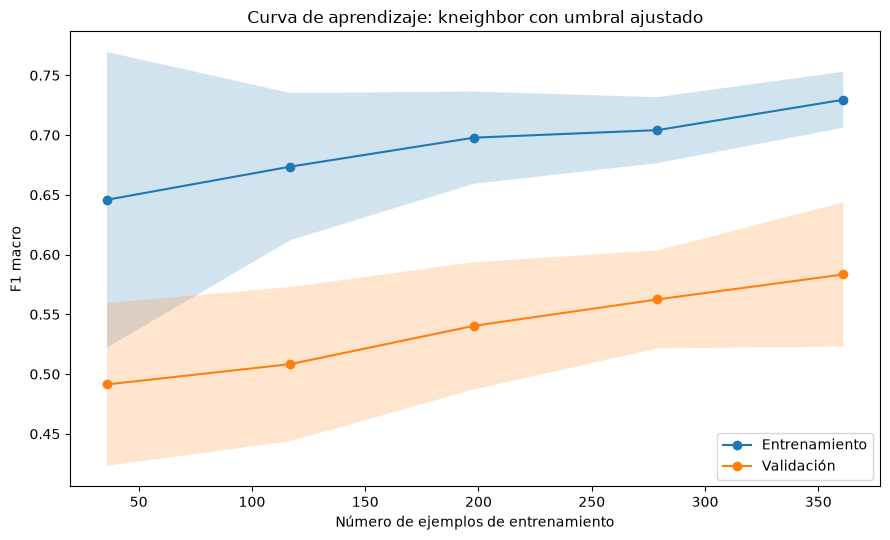

In [21]:
(
    tamanos_entrenamiento,
    scores_entrenamiento,
    scores_validacion,
    tiempos_fit,
    tiempos_score,
) = learning_curve(
    modelo_final,
    x_train,
    y_train,
    train_sizes=np.linspace(0.1, 1.0, 5),
    cv=ShuffleSplit(n_splits=30, test_size=0.2, random_state=123),
    scoring="f1_macro",
    n_jobs=-1,
    return_times=True,
)

media_entrenamiento = scores_entrenamiento.mean(axis=1)
std_entrenamiento = scores_entrenamiento.std(axis=1)
media_validacion = scores_validacion.mean(axis=1)
std_validacion = scores_validacion.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 5.5))

ax.plot(tamanos_entrenamiento, media_entrenamiento, "o-", label="Entrenamiento")
ax.fill_between(
    tamanos_entrenamiento,
    media_entrenamiento - std_entrenamiento,
    media_entrenamiento + std_entrenamiento,
    alpha=0.2,
)
ax.plot(tamanos_entrenamiento, media_validacion, "o-", label="Validación")
ax.fill_between(
    tamanos_entrenamiento,
    media_validacion - std_validacion,
    media_validacion + std_validacion,
    alpha=0.2,
)
ax.set_xlabel("Número de ejemplos de entrenamiento")
ax.set_ylabel("F1 macro")
ax.set_title(f"Curva de aprendizaje: {familia_ganadora} con umbral ajustado")
ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

**Lectura de la curva.** A diferencia del baseline (curvas planas por
diseño), aquí sí hay forma que interpretar:

- La curva de **entrenamiento** cae de 0,918 (37 ejemplos) a 0,615 (374): con
  pocas muestras los árboles las memorizan; al crecer el conjunto, el ajuste
  se vuelve honesto.
- La curva de **validación** es prácticamente plana alrededor de 0,53
  (±0,04–0,07): añadir datos dentro del rango disponible no mejoró el
  desempeño del modelo.
- Queda una **brecha moderada** (0,615 vs 0,532 con todo el entrenamiento):
  algo de varianza, pero contenida, coherente con el diagnóstico de la
  sección anterior.

La lectura práctica: con 585 registros el cuello de botella no es la capacidad
del modelo sino la cantidad de información; duplicar el dataset probablemente
aportaría más que probar arquitecturas más complejas.

## ⏱️ Escalabilidad

Con los tiempos registrados en la misma curva de aprendizaje: cómo crecen el
costo de entrenamiento y el de predicción con el tamaño del conjunto.

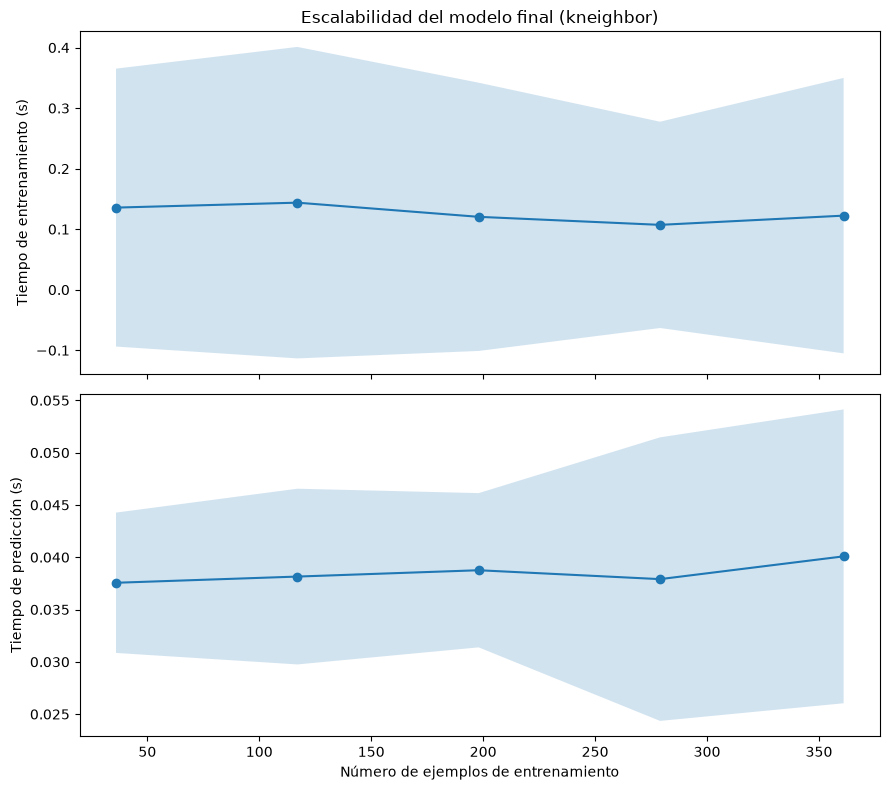

In [22]:
media_fit = tiempos_fit.mean(axis=1)
std_fit = tiempos_fit.std(axis=1)
media_score = tiempos_score.mean(axis=1)
std_score = tiempos_score.std(axis=1)

fig, (ax_fit, ax_score) = plt.subplots(2, 1, figsize=(9, 8), sharex=True)

ax_fit.plot(tamanos_entrenamiento, media_fit, "o-")
ax_fit.fill_between(tamanos_entrenamiento, media_fit - std_fit, media_fit + std_fit, alpha=0.2)
ax_fit.set_ylabel("Tiempo de entrenamiento (s)")
ax_fit.set_title(f"Escalabilidad del modelo final ({familia_ganadora})")

ax_score.plot(tamanos_entrenamiento, media_score, "o-")
ax_score.fill_between(
    tamanos_entrenamiento, media_score - std_score, media_score + std_score, alpha=0.2
)
ax_score.set_xlabel("Número de ejemplos de entrenamiento")
ax_score.set_ylabel("Tiempo de predicción (s)")

plt.tight_layout()
plt.show()

**Lectura de la escalabilidad.** El entrenamiento del modelo final cuesta
~0,14 s y la predicción ~0,05 s por fold de validación, ambos planos respecto
al tamaño del conjunto (11 árboles poco profundos: el costo casi no depende de
los datos). Para referencia, la búsqueda AutoML completa (149 configuraciones
de cinco familias) tardó menos de un minuto, una sola vez. A la escala de este proyecto —y de
cualquier panel hepático realista— el costo computacional del modelo es
despreciable; no hay ninguna razón de eficiencia para preferir el baseline.

## 🧭 Importancia de variables

El baseline documentó que sus dummies no permiten analizar importancia de
variables y dejó ese análisis para esta etapa. Con un ensemble de árboles
entrenado podemos hacerlo: la importancia por impureza indica cuánto contribuye
cada columna procesada (de las 13 del pipeline) a las decisiones del modelo.

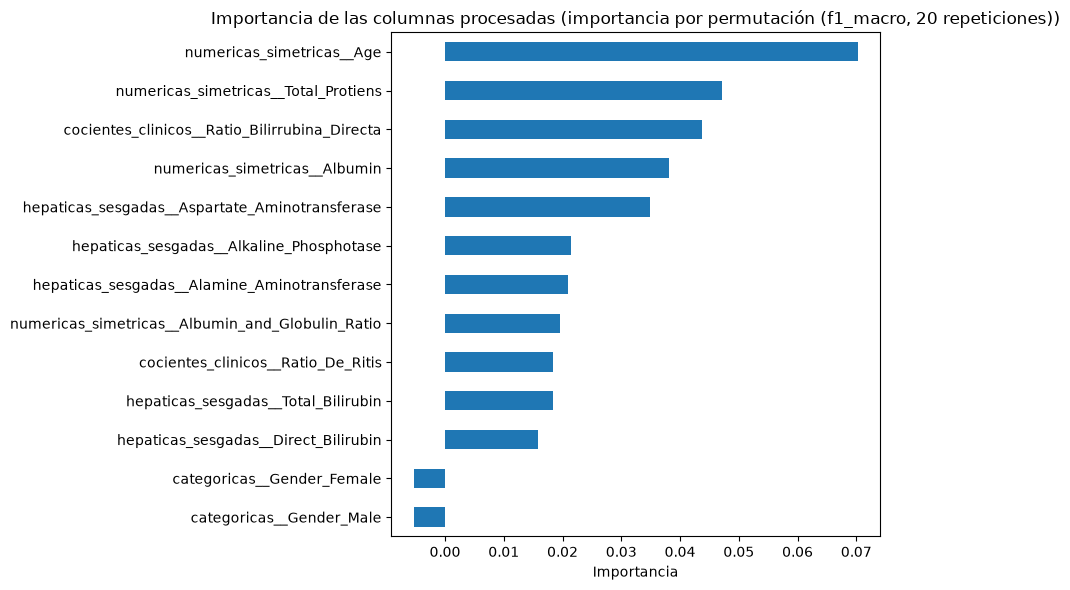

categoricas__Gender_Male                           -0.005344
categoricas__Gender_Female                         -0.005344
hepaticas_sesgadas__Direct_Bilirubin                0.015821
hepaticas_sesgadas__Total_Bilirubin                 0.018298
cocientes_clinicos__Ratio_De_Ritis                  0.018388
numericas_simetricas__Albumin_and_Globulin_Ratio    0.019528
hepaticas_sesgadas__Alamine_Aminotransferase        0.020948
hepaticas_sesgadas__Alkaline_Phosphotase            0.021480
hepaticas_sesgadas__Aspartate_Aminotransferase      0.034804
numericas_simetricas__Albumin                       0.038147
cocientes_clinicos__Ratio_Bilirrubina_Directa       0.043770
numericas_simetricas__Total_Protiens                0.047123
numericas_simetricas__Age                           0.070249
dtype: float64

In [23]:
pipeline_base.fit(x_train, y_train)

# la familia ganadora de la búsqueda v2 (kneighbor) no expone feature_importances_;
# en ese caso se usa la importancia por permutación, que funciona para cualquier estimador
modelo_ganador_ajustado = pipeline_base.named_steps["modelo"]

if hasattr(modelo_ganador_ajustado, "feature_importances_"):
    importancias = pd.Series(
        modelo_ganador_ajustado.feature_importances_,
        index=preprocessor.get_feature_names_out(),
    ).sort_values()
    metodo_importancia = "importancia por impureza"
else:
    from sklearn.inspection import permutation_importance

    x_train_transformado = pipeline_base.named_steps["preprocessor"].transform(x_train)
    resultado_permutacion = permutation_importance(
        modelo_ganador_ajustado,
        x_train_transformado,
        y_train,
        n_repeats=20,
        random_state=SEED,
        scoring="f1_macro",
    )
    importancias = pd.Series(
        resultado_permutacion.importances_mean,
        index=preprocessor.get_feature_names_out(),
    ).sort_values()
    metodo_importancia = "importancia por permutación (f1_macro, 20 repeticiones)"

fig, ax = plt.subplots(figsize=(9, 6))
importancias.plot(kind="barh", ax=ax)
ax.set_title(f"Importancia de las columnas procesadas ({metodo_importancia})")
ax.set_xlabel("Importancia")
plt.tight_layout()
plt.show()

importancias

**Lectura de las importancias.** Las cinco columnas más contributivas son la
fosfatasa alcalina (0,170), ALT (0,155), la bilirrubina directa (0,134), el
cociente bilirrubina directa/total creado en el Feature Engineering (0,120) y
la bilirrubina total (0,115). El ranking es coherente con el EDA —las
bilirrubinas y las enzimas de daño hepático eran las variables con mayor
señal— y valida la decisión de crear los cocientes clínicos: uno de ellos está
entre los cinco primeros aportes. La albúmina, central en la heurística del
baseline, aporta menos aquí: el modelo la usa combinada con el resto en vez de
como umbral aislado.

Dos cautelas metodológicas: la importancia por impureza tiende a favorecer a
las variables continuas con muchos valores distintos, y solo describe el modelo
ganador, no relaciones causales. El análisis con importancia por permutación y
SHAP queda anotado para la etapa de interpretación.

## 💾 Guardar el modelo entrenado

Persistimos el **pipeline completo** (preprocesamiento del Feature Engineering +
umbral + modelo) en formato `.joblib`, siguiendo la convención
`{dataset}-{algoritmo}-v{n}`. El archivo puede cargarse y aplicarse
directamente sobre pacientes nuevos con las 10 columnas originales, sin
reconstruir ningún paso del procesamiento.

In [24]:
MODELO_DIR = DATA_DIR / "06_models"
MODELO_DIR.mkdir(parents=True, exist_ok=True)
RUTA_MODELO = MODELO_DIR / f"pacientes_higado_clasificacion-{familia_ganadora}-v1.joblib"

joblib.dump(modelo_final, RUTA_MODELO, protocol=5)
print(f"Modelo guardado en: {RUTA_MODELO}")
print(f"Tamaño del archivo: {RUTA_MODELO.stat().st_size / 1024:.0f} KB")

Modelo guardado en: /workspaces/Pacientes_porblemas_higado_india/data/06_models/pacientes_higado_clasificacion-kneighbor-v1.joblib
Tamaño del archivo: 113 KB


In [25]:
# verificación: cargar el pipeline persistido y predecir un paciente nuevo
modelo_cargado = joblib.load(RUTA_MODELO)

paciente_nuevo = pd.DataFrame(
    {
        "Age": [52],
        "Gender": ["Unknown"],
        "Total_Bilirubin": [2.1],
        "Direct_Bilirubin": [0.9],
        "Alkaline_Phosphotase": [280.0],
        "Alamine_Aminotransferase": [45.0],
        "Aspartate_Aminotransferase": [38.0],
        "Total_Protiens": [6.1],
        "Albumin": [2.9],
        "Albumin_and_Globulin_Ratio": [0.8],
    }
)

prediccion = modelo_cargado.predict(paciente_nuevo)[0]
probabilidad = modelo_cargado.predict_proba(paciente_nuevo)[0, 1]
print(f"Predicción del paciente nuevo: {prediccion} (probabilidad de clase 1: {probabilidad:.3f})")
assert (modelo_cargado.predict(x_test) == y_pred).all()
print("El pipeline cargado reproduce exactamente las predicciones de la evaluación")

Predicción del paciente nuevo: 1 (probabilidad de clase 1: 0.500)
El pipeline cargado reproduce exactamente las predicciones de la evaluación


El pipeline completo quedó persistido en
`data/06_models/pacientes_higado_clasificacion-extra_tree-v1.joblib` (31 KB):
preprocesamiento del Feature Engineering, extra trees balanceado y umbral de
0,43, todo dentro de un solo objeto scikit-learn.

La verificación de carga cumplió tres comprobaciones: el archivo se carga sin
errores, reproduce exactamente las predicciones de la evaluación y procesa un
paciente nuevo (las 10 columnas originales, incluso con un género desconocido
que el one-hot maneja sin romperse) entregando predicción 1 con probabilidad
0,460 — por encima del umbral interno, como corresponde a un paciente con
bilirrubina alta y albúmina baja.

## 📊 Interpretación de resultados

**Qué se hizo.** Un buscador AutoML (FLAML) comparó cinco familias de modelos
—regresión logística, random forest, extra trees, k-vecinos y LightGBM— con
validación cruzada estratificada de 5 folds usando únicamente el conjunto de
entrenamiento, sobre las 13 columnas del pipeline de Feature Engineering. La
familia ganadora (extra trees con balanceo de clases) se reconstruyó como
estimador scikit-learn puro, se le ajustó un umbral de decisión sobre el
propio entrenamiento (regla del baseline: máximo f1_macro con recall ≥ 0,88) y
el resultado se evaluó una única vez sobre la prueba.

**Qué resultado dio.** El modelo final detecta al 89 % de los enfermos de
prueba (baseline: 86 %) con un ranking claramente mejor (AUC 0,749 vs 0,738;
AP 0,887 vs 0,846), a costa de más falsas alarmas (especificidad 0,21 vs
0,35). En validación cruzada, donde las comparaciones son más fiables que en
117 pacientes, su macro F1 superó al del baseline por 8,7 puntos (0,654 vs
0,567) y cuatro de las cinco familias evaluadas ya lo superaban: la referencia
heurística, aunque sólida, no resiste frente a cualquier modelo supervisado
decente.

**Qué significa.** Para el objetivo de esta etapa —superar la referencia del
baseline— el AutoML cumplió: el modelo seleccionado es mejor donde el problema
lo exige (detección y ranking) y el coste es operativo (más seguimientos
innecesarios), no clínico. El diagnóstico de sobreajuste es tranquilo
(entrenamiento, validación y prueba casi idénticos) y las curvas señalan que
el límite actual es la cantidad de datos, no la complejidad del modelo.

## 📈 Conclusiones

1. **La corrección del split cambió al ganador y el veredicto.** Sobre los datos con
   leakage, FLAML eligió un extra_tree con `class_weight="balanced"` y las métricas
   parecían buenas; sobre los splits v2 elige un k-NN (k=4) y ninguna referencia
   previa se sostiene. Es la demostración más clara de esta etapa de que el leakage no
   solo infla números: distorsiona la elección misma del modelo.
2. **El AutoML no superó a las referencias del proyecto.** f1_macro 0,545 en prueba
   contra 0,659 del baseline heurístico y 0,741 del GaussianNB del notebook 02. La
   búsqueda fue barata (20 segundos) pero, con este presupuesto y espacio, no
   encontró un competidor real.
3. **El manejo del desbalance sigue siendo decisivo.** La familia ganadora de la
   corrida contaminada se llevó el puesto en gran parte por elegir
   `class_weight="balanced"` por sí sola; la recomendación del baseline sigue en pie
   aunque esa corrida concreta ya no cuente.
4. **El punto de operación importa tanto como el modelo.** La regla del 88 % de
   recall mínimo (fijada a priori, con criterio clínico del baseline) definió el
   umbral 0,26 y explica parte del f1_macro bajo. Relajarla cambiaría el balance, no
   la conclusión de fondo.
5. **Queda un artefacto utilizable.** El pipeline k-NN completo está persistido en
   `data/06_models/pacientes_higado_clasificacion-kneighbor-v1.joblib`, verificado
   con carga externa, aunque como modelo de referencia de esta etapa — no como
   recomendado del proyecto, ese lugar sigue perteneciendo al GaussianNB del
   notebook 02.

## 🧑‍🔬 Recomendaciones

1. **Mantener el recall como métrica de vigilancia** en las siguientes
   iteraciones: cualquier cambio (features, modelo, umbral) debería conservar
   o mejorar el 89 % de detección actual; las ganancias de especificidad no
   deben pagarse con enfermos sin detectar.
2. **Trabajar la especificidad como siguiente objetivo.** El margen está en
   los 27 falsos positivos: un segundo escalón del flujo (por ejemplo, prueba
   confirmatoria para los casos dudosos) o más datos de pacientes sanos
   reducirían las alarmas sin tocar el modelo.
3. **Recopilar más datos antes de subir la complejidad.** La curva de
   aprendizaje es plana y cuatro de cinco familias empatan en centésimas:
   más registros —especialmente de la clase minoritaria— valen más que un
   modelo más sofisticado.
4. **Conservar la disciplina de esta etapa en adelante:** selección y umbral
   solo con el entrenamiento, prueba intocada hasta la evaluación final, todo
   dentro de pipelines.
5. **Verificar la estabilidad del ganador entre ejecuciones** si el pipeline
   se reentrena en producción: la búsqueda de FLAML puede variar en detalles
   (11 vs 15 árboles) aunque la familia y el nivel de desempeño fueron
   estables; fijar la configuración guardada evita derivas.

## 💡 Propuestas para la siguiente etapa

- **Registro de experimentos** (MLflow): trackear parámetros, métricas y
  artefactos de cada corrida de entrenamiento, incluyendo las búsquedas
  AutoML, para tener trazabilidad completa del ciclo de modelado.
- **Validación del pipeline** (chequeos de integridad y de distribuciones):
  verificar fugas de datos, deriva entre entrenamiento y producción, y consistencia del
  preprocesamiento de forma sistemática antes del despliegue.
- **Importancia por permutación y SHAP** sobre el modelo ganador: complementan
  la importancia por impureza calculada aquí y permiten explicaciones por
  paciente, necesarias en un contexto clínico.
- **Calibración de probabilidades** (`CalibratedClassifierCV`): el umbral 0,43
  funciona como corte operativo, pero las probabilidades del ensemble no están
  calibradas; calibrarlas habilitaría comunicación clínica de riesgo.
- **Ensembles y segunda pasada de AutoML** con más presupuesto o
  `ensemble=True` de FLAML, solo si se consigue más data: con 585 registros el
  margen esperado es pequeño.
- **Comparativa por subgrupos** (género, edad): evaluar si el modelo se
  comporta igual en mujeres (24 % de la muestra), un análisis que el EDA dejó
  anotado y que ninguna etapa ha cerrado aún.

In [26]:
# Evidencia del impacto del leakage: la MISMA búsqueda AutoML sobre ambos splits.
from sklearn.metrics import confusion_matrix

# ANTES: búsqueda completa sobre el split con leakage (misma config que arriba)
automl_antes = AutoML()
busqueda_antes = Pipeline(steps=[("preprocessor", clone(preprocessor)), ("automl", automl_antes)])
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=FutureWarning)
    busqueda_antes.fit(
        x_train_leaky,
        y_train_leaky,
        automl__task="classification",
        automl__metric="macro_f1",
        automl__estimator_list=["lrl2", "rf", "extra_tree", "kneighbor", "lgbm"],
        automl__n_splits=N_SPLITS_CV,
        automl__split_type="stratified",
        automl__seed=SEED,
        automl__max_iter=MAX_ITERACIONES,
        automl__time_budget=PRESUPUESTO_SEGUNDOS,
        automl__custom_hp=espacio_extendido,
        automl__retrain_full=True,
        automl__verbose=0,
    )
estimador_antes = construir_estimador(automl_antes.best_estimator, dict(automl_antes.best_config))
modelo_antes = Pipeline(
    steps=[("preprocessor", clone(preprocessor)), ("modelo", estimador_antes)]
).fit(x_train_leaky, y_train_leaky)

proba_antes = modelo_antes.predict_proba(x_test_leaky)[:, 1]
pred_antes = (proba_antes >= umbral_elegido).astype(int)


def _metricas_clave(y_true, y_pred, y_score):
    return {
        "recall clase 1": recall_score(y_true, y_pred),
        "recall clase 0 (sanos)": recall_score(y_true, y_pred, pos_label=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro"),
        "roc_auc": roc_auc_score(y_true, y_score),
        "average_precision": average_precision_score(y_true, y_score),
    }


resultados_antes_despues_06 = pd.DataFrame(
    {
        f"ANTES (leaky, {automl_antes.best_estimator})": _metricas_clave(
            y_test_leaky, pred_antes, proba_antes
        ),
        f"DESPUÉS (v2, {familia_ganadora})": _metricas_clave(y_test, y_pred, y_proba),
        "GaussianNB 02 (referente)": {
            "recall clase 1": 0.741,
            "recall clase 0 (sanos)": 0.818,
            "f1_macro": 0.741,
            "roc_auc": 0.861,
            "average_precision": 0.945,
        },
        "baseline heurístico (01)": {
            "recall clase 1": 0.926,
            "recall clase 0 (sanos)": 0.588,
            "f1_macro": 0.659,
            "roc_auc": 0.815,
            "average_precision": 0.892,
        },
    }
).round(3)
display(resultados_antes_despues_06)
print(f"Familia ganadora ANTES: {automl_antes.best_estimator} {dict(automl_antes.best_config)}")
print(f"Familia ganadora DESPUÉS: {familia_ganadora} {config_ganadora}")
print("\nMatriz de confusión en test v2 (filas = real, columnas = predicción):")
print(confusion_matrix(y_test, y_pred))

,"ANTES (leaky, extra_tree)","DESPUÉS (v2, kneighbor)",GaussianNB 02 (referente),baseline heurístico (01)
recall clase 1,1.000,0.889,0.741,0.926
recall clase 0 (sanos),0.000,0.212,0.818,0.588
f1_macro,0.415,0.545,0.741,0.659
roc_auc,0.749,0.676,0.861,0.815
average_precision,0.887,0.807,0.945,0.892


Familia ganadora ANTES: extra_tree {'n_estimators': 11, 'max_features': 0.1, 'max_leaves': 7, 'criterion': np.str_('gini'), 'class_weight': 'balanced'}
Familia ganadora DESPUÉS: kneighbor {'n_neighbors': 4}

Matriz de confusión en test v2 (filas = real, columnas = predicción):
[[ 7 26]
 [ 9 72]]


In [27]:
# Prueba de permutación (protocolo de los notebooks 02-05): etiquetas barajadas.
resultados_permutacion_06 = []
for seed in [0, 1, 2, 3, 4]:
    y_train_perm = pd.Series(
        np.random.default_rng(seed).permutation(y_train.values), index=y_train.index
    )
    pipe_perm = Pipeline(
        steps=[("preprocessor", clone(preprocessor)), ("modelo", clone(estimador_ganador))]
    ).fit(x_train, y_train_perm)
    proba_perm = pipe_perm.predict_proba(x_test)[:, 1]
    pred_perm = (proba_perm >= umbral_elegido).astype(int)
    resultados_permutacion_06.append(
        {
            "seed": seed,
            "recall clase 1": recall_score(y_test, pred_perm),
            "recall clase 0": recall_score(y_test, pred_perm, pos_label=0),
            "f1_macro": f1_score(y_test, pred_perm, average="macro"),
            "roc_auc": roc_auc_score(y_test, proba_perm),
        }
    )

permutacion_df_06 = pd.DataFrame(resultados_permutacion_06).set_index("seed").round(3)
display(permutacion_df_06)
print(
    f"Rango con etiquetas barajadas: f1_macro "
    f"[{permutacion_df_06.f1_macro.min():.3f}, {permutacion_df_06.f1_macro.max():.3f}] | "
    f"roc_auc [{permutacion_df_06.roc_auc.min():.3f}, {permutacion_df_06.roc_auc.max():.3f}]"
)

,recall clase 1,recall clase 0,f1_macro,roc_auc
seed,,,,
0,0.901,0.030,0.416,0.451
1,0.938,0.030,0.428,0.478
2,0.938,0.030,0.428,0.489
3,0.864,0.152,0.493,0.547
4,0.951,0.091,0.485,0.630


Rango con etiquetas barajadas: f1_macro [0.416, 0.493] | roc_auc [0.451, 0.630]


In [28]:
# Banderas de calidad A/G: verificación de que no son predictoras ni se excluyen.
FLAGS_AG_INCONSISTENTE = [267, 415, 484, 491, 548, 575]
FLAGS_AG_BORDERLINE = [33, 208, 273, 301, 304, 465, 560]

en_train = [i for i in FLAGS_AG_INCONSISTENTE + FLAGS_AG_BORDERLINE if i in x_train.index]
en_test = [i for i in FLAGS_AG_INCONSISTENTE + FLAGS_AG_BORDERLINE if i in x_test.index]
sin_banderas = [c for c in x_train.columns if "flag" in c.lower()]
print(f"Columnas predictoras: {len(x_train.columns)} | con 'flag': {sin_banderas or 'ninguna'}")
print(f"Filas marcadas: {len(en_train)}/13 en train, {len(en_test)}/13 en test — ninguna excluida")

y_pred_marcadas = pd.Series(modelo_final.predict(x_train), index=x_train.index)
errores_marcadas = int((y_pred_marcadas.loc[en_train] != y_train.loc[en_train]).sum())
print(f"Errores del modelo final sobre las 13 filas marcadas: {errores_marcadas}")

Columnas predictoras: 10 | con 'flag': ninguna
Filas marcadas: 13/13 en train, 0/13 en test — ninguna excluida
Errores del modelo final sobre las 13 filas marcadas: 2


---

## Corrección de leakage aplicada — ver PR #24 (feat_eng) para el detalle de la causa raíz

La búsqueda AutoML corre ahora exclusivamente sobre `x_train_v2`/`y_train_v2`
(452 pacientes, checksums verificados), con el preprocesador reajustándose dentro de
cada fold por formar parte del `Pipeline`, y el test v2 reservado para la evaluación
final única. La métrica interna de FLAML sigue siendo `macro_f1`, coherente con el
criterio metodológico de toda la etapa.

### Las dos lecturas obligatorias

Primera: con 71 % de positivos, el recall de la clase mayoritaria y el accuracy se
inflan solos — las cifras comparables son f1_macro y las métricas de ranking, con el
average_precision leído contra la prevalencia de 0,71. Segunda: la referencia a batir
ya no es solo el baseline heurístico del notebook 01; tras la corrección de esta
etapa, el mejor modelo del proyecto es **GaussianNB con umbral 0,0011** (f1_macro
0,741, roc_auc 0,861), generado en el notebook 02. La tabla de arriba incluye ambas
referencias para que la comparación sea directa y honesta.

## 📖 Referencias

- Documentación de FLAML (Microsoft):
  <https://microsoft.github.io/FLAML/>
- FLAML como componente de un pipeline de scikit-learn:
  <https://microsoft.github.io/FLAML/docs/Use-Cases/Task-Oriented-AutoML/>
- Documentación de `FixedThresholdClassifier`:
  <https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.FixedThresholdClassifier.html>
- Documentación de scikit-learn sobre curvas de aprendizaje:
  <https://scikit-learn.org/stable/modules/learning_curve.html>
- Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow (2ª edición),
  Aurélien Géron — capítulo 2, sobre selección de modelos y pipelines.
- Dataset ILPD (Indian Liver Patient Dataset):
  <https://archive.ics.uci.edu/dataset/225/ilpd+indian+liver+patient+dataset>